# XMLD Ptycho notebook

Standard vector ptychography solves for a general Jones matrix using polarization diversity and analysis.

Here, we instead embed the physics of XMLD scattering directly into the forward model, reducing the number of unknowns and enabling reconstruction without polarization analysis.

First generate code to simulate the speckle pattern for a Neel texture for several given probes (of different linear polarisations).
* The sample (object) is now represented by pixels each of which is a complex Jones Matrix. This Jones matrix is able to act on different polarisations differently
* The Jones Matrix is constructed from a Neel field (parametrised by $\theta$ and $\phi$)
* Several probes are now needed, each with a different Jones vector
* A tensor of diffraction patterns are now collected of shape 


Is it better to use the PtyPy framework already present?

https://ptycho.github.io/ptypy/rst/concept.html

What about this:
https://dherrera1911.github.io/posts/2024/08/constrained-learning-with-pytorch-parametrizations/

In [126]:
import importlib
import vector_ptycho.utils as vpu
importlib.reload(vpu)
from vector_ptycho.utils import *
import numpy as np
import matplotlib.pyplot as plt
import torch
import pickle


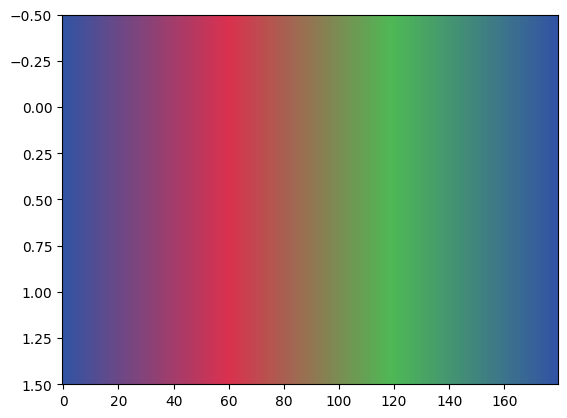

In [99]:
RGB_scale = make_vector_color_map()

## Construct a Jones Matrix as follows from a Meron-Antimeron pair as follows:
The complex Jones matrix acts on a Jones vector (probe) to produce an exit wave just after the sample. We have a probe which gets translated $P_{jk}(\textbf{r}) = P_{k}(r -r_j)$ which corresponds to the $k^{th}$ polarisation state at the $j^{th}$ position.
$$
\mathbf{\Psi_{jk}(r)} = O(\textbf{r})P_{jk}(\textbf{r})=
\begin{pmatrix}
\rho_{xx}(\textbf{r})
&
\rho_{yx}(\textbf{r})
\\
\rho_{xy}(\textbf{r})
&
\rho_{yy}(\textbf{r})
\end{pmatrix}
\begin{pmatrix}
P_{jk;x}(\textbf{r})
\\
P_{jk;y}(\textbf{r})
\end{pmatrix}
$$

For impure states we should use a density matrix formalism. In that case we would be representing the probe as a matrix which contains 
Now since we are interested in constructing the Neel field on the sample $\phi(\textbf{r})$ and $\theta(\textbf{r})$ we can write the Jones matrix in terms of the Neel vector direction. On-diagonal elements are a combination of charge scattering $C$ and XMLD. Offdiagonal elements are XMLD scattering of polarisation into different channels
$$
\mathbf{O} =
\begin{pmatrix}
C + A_1 \cos^2\!\phi \, \sin^2\!\theta + A_2 \cos^2\!\theta
&
A_2 \sin\!\phi \, \cos\!\phi \, \sin^2\!\theta
\\
A_2 \sin\!\phi \, \cos\!\phi \, \sin^2\!\theta
&
C + A_1 \sin^2\!\phi \, \sin^2\!\theta + A_2 \cos^2\!\theta
\end{pmatrix}
$$

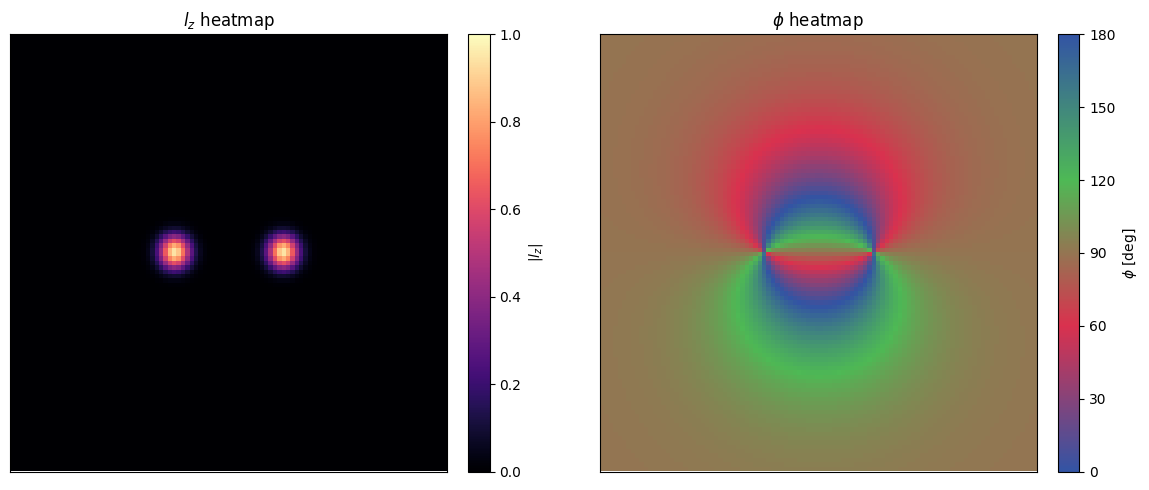

<Figure size 640x480 with 0 Axes>

theta range: [0.339, 2.803]
phi range: [0.012, 6.281]
Mx range: [-1.000, 1.000]
My range: [-0.997, 1.000]
Mz range: [-0.943, 0.943]
Jones object built with shape: torch.Size([100, 100, 2, 2])
Jones object dtype: torch.complex64
An example Jones matrix at the center pixel:
 tensor([[ 5.0003e+01+50.0326j, -4.0255e-02-0.4026j],
        [-4.0255e-02-0.4026j,  5.0497e+01+54.9674j]])


In [100]:
# =========================
# Example usage
# =========================
H, W = 100, 100
Lx = 10
Ly = 10

# Build theta, phi from meron-antimeron generator (returns torch tensors)
theta, phi, Mx, My, Mz = make_meron_antimeron_theta_phi(
    Nx=W,
    Ny=H,
    Lx=Lx,
    Ly=Ly,
    plot=True,
    save_path=None,
    export_path=None,
    return_torch=True,
    out_device=device,
    cm = RGB_scale
)

print('theta range: [{:.3f}, {:.3f}]'.format(theta.min().item(), theta.max().item()))
print('phi range: [{:.3f}, {:.3f}]'.format(phi.min().item(), phi.max().item()))

print('Mx range: [{:.3f}, {:.3f}]'.format(Mx.min().item(), Mx.max().item()))
print('My range: [{:.3f}, {:.3f}]'.format(My.min().item(), My.max().item()))
print('Mz range: [{:.3f}, {:.3f}]'.format(Mz.min().item(), Mz.max().item()))

# Physical XMLD/Jones constants
C = torch.tensor(50.0+ 50.0j, dtype=cdtype, device=device)
A1 = torch.tensor(0.5 + 5j, dtype=cdtype, device=device)
A2 = torch.tensor(0.8 + 5j, dtype=cdtype, device=device)

# Build Jones object from theta, phi
neel = NeelObject(C, A1, A2)
J = neel.build_jones(theta, phi)
obj = JonesObject(J)
print('Jones object built with shape:', J.shape)
print('Jones object dtype:', J.dtype)
print('An example Jones matrix at the center pixel:\n', J[H//2, W//2])



In [101]:
J_0_0 = J[50,50]
print('Jones matrix:\n', J_0_0)
print('Jxx:\n', J_0_0[0,0])
print('Jxy:\n', J_0_0[0,1])
print('Jyx:\n', J_0_0[1,0])
print('Jyy:\n', J_0_0[1,1])


Jones matrix:
 tensor([[ 5.0003e+01+50.0326j, -4.0255e-02-0.4026j],
        [-4.0255e-02-0.4026j,  5.0497e+01+54.9674j]])
Jxx:
 tensor(50.0033+50.0326j)
Jxy:
 tensor(-0.0403-0.4026j)
Jyx:
 tensor(-0.0403-0.4026j)
Jyy:
 tensor(50.4967+54.9674j)


Jones vector for 0 deg linear polarisation: tensor([1.+0.j, 0.+0.j])
Jones vector for 30 deg linear polarisation: tensor([0.8660+0.j, 0.5000+0.j])
Jones vector for 60 deg linear polarisation: tensor([0.5000+0.j, 0.8660+0.j])
Jones vector for 90 deg linear polarisation: tensor([6.1232e-17+0.j, 1.0000e+00+0.j])
Defined 4 probes with different linear polarisation states.


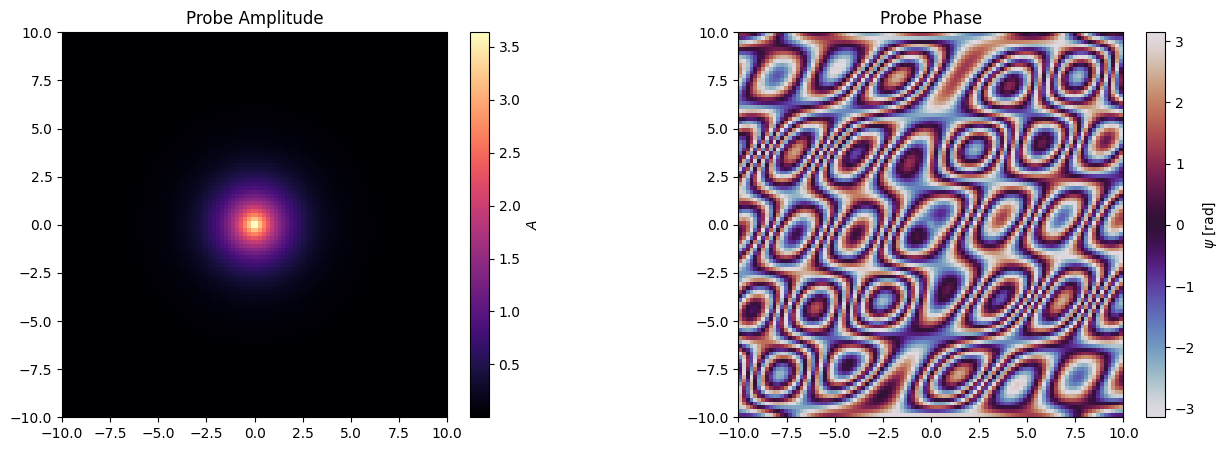

tensor(1000., dtype=torch.float64)


In [102]:
# Grid for probe definition
x = torch.linspace(-Lx, Lx, H, device=device)
y = torch.linspace(-Ly, Ly, W, device=device)
X, Y = torch.meshgrid(x, y, indexing='ij')

fluence = torch.scalar_tensor(1e3, dtype=torch.float64, device=device)
R=torch.sqrt(X**2+Y**2) #This helps with defining the probe

Diffuser = 0.8*(torch.sin(1*R)+torch.cos((Y*1+X*1)-0.8*(X-0.2))+torch.cos((Y-X)-0.4*(X))) #(torch.sqrt(3*X**2+1.5*Y**2)+torch.pi/3)#*(torch.exp(-0.1*R)) #np.mod(0.1*(torch.sin(150*R)+torch.cos((Y*10+X*30)**2-0.8*(X*75-0.2))+torch.cos((Y*10-X*33)**2-0.4*(X*50-0.2))),1)

P = torch.zeros_like(R)
P = torch.exp(2j*np.pi*Diffuser)*(torch.exp(-0.8*R))


probes = []
# Calculate the Jones vectors of the probes for different Linear polarisation states
pol_angles = [0, 30, 60, 90]
for angle in pol_angles:
    rad = np.deg2rad(angle)
    jones_vec = torch.tensor([np.cos(rad) + 0j, np.sin(rad) + 0j], dtype=cdtype, device=device)
    print(f'Jones vector for {angle} deg linear polarisation: {jones_vec}')
    probes.append(Probe(P, jones_vec, fluence=fluence, normalized=False))

print('Defined {} probes with different linear polarisation states.'.format(len(probes)))


plot_probe_maps(probes[0].amplitude, Lx, Ly)
print(probes[0].fluence)

In [103]:
probe = probes[0]
probe_amplitude = probe.amplitude_scaled
fluence_calc = torch.sum(torch.abs(probe_amplitude)**2)
print('Calculated fluence from probe amplitude:', fluence_calc.item())

Calculated fluence from probe amplitude: 1000.0


In [104]:
xshiftvec = torch.linspace(-5, 5,10)
yshiftvec = torch.linspace(-5, 5,10)

# Shifting the text so that we can plot on the data
dx = (xshiftvec[1] - xshiftvec[0]) / 10
dy = (yshiftvec[1] - yshiftvec[0]) / 10

# Lab-coordinate scan grid used for plotting
xpos_lab, ypos_lab = torch.meshgrid(xshiftvec, yshiftvec, indexing="ij")
positions = torch.stack([ypos_lab.flatten(), xpos_lab.flatten()], dim=1)

# Convert lab coordinates into discrete pixel shifts for torch.roll(row, col)
pixel_size_y = (2 * Ly) / (H - 1)
pixel_size_x = (2 * Lx) / (W - 1)
positions_idx = torch.stack([
    torch.round(positions[:, 0] / pixel_size_y),
    torch.round(positions[:, 1] / pixel_size_x),
], dim=1).to(torch.int64)

scan = ScanTrajectory(positions_idx)


C:\Users\godfrey\OneDrive - Nexus365\Documents\Google Drive (old computer 12_07_2022)\PhD\Year 3\Term 1\Ptycho\vector-ptycho\src\vector_ptycho\utils.py:353: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.positions = torch.tensor(positions, device=device)


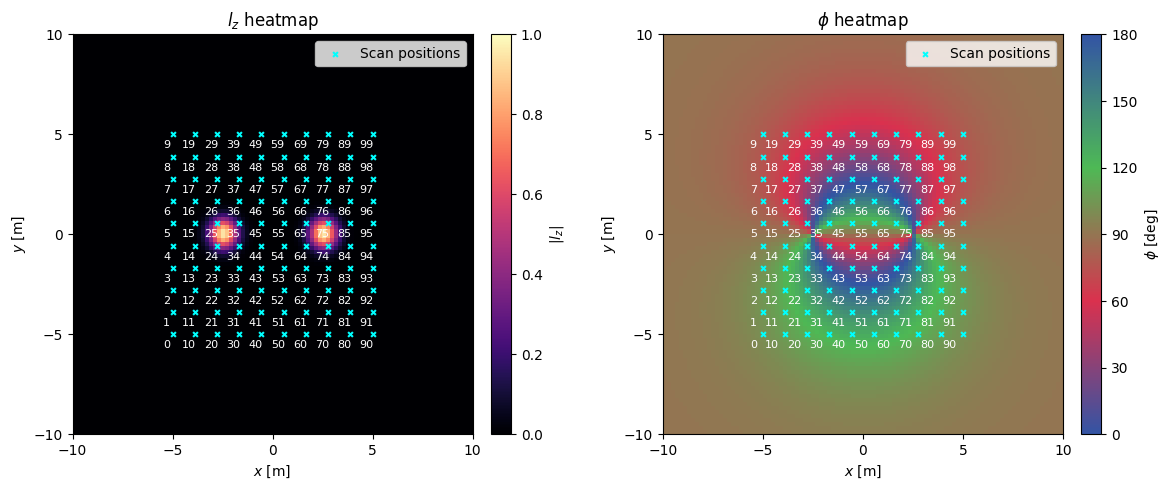

(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': '$l_z$ heatmap'}, xlabel='$x$ [m]', ylabel='$y$ [m]'>,
        <Axes: title={'center': '$\\phi$ heatmap'}, xlabel='$x$ [m]', ylabel='$y$ [m]'>],
       dtype=object))

In [105]:
plot_theta_phi_maps(theta, phi, Lx, Ly,theta_cmap='magma',
                       phi_cmap=RGB_scale,
                       positions=positions, dx=0.3, dy=0.3, show_positions=True, label_positions=True, label_axes=True)

In [106]:
# Forward model
model = ForwardModel(obj, Propagator(), Detector(add_poisson_noise=True))
I_sim = model.simulate_all(probes, scan)
print('Simulated data shape:', I_sim.shape)  # (N_probes, N_positions, H, W)

Simulated data shape: torch.Size([4, 100, 100, 100])


In [107]:
print(positions[59])

tensor([5.0000, 0.5556])


C:\Users\godfrey\AppData\Local\Temp\ipykernel_23364\1522270205.py:19: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  np.log10(I_sim[probe_number, scan_idx].cpu()+1e-8),


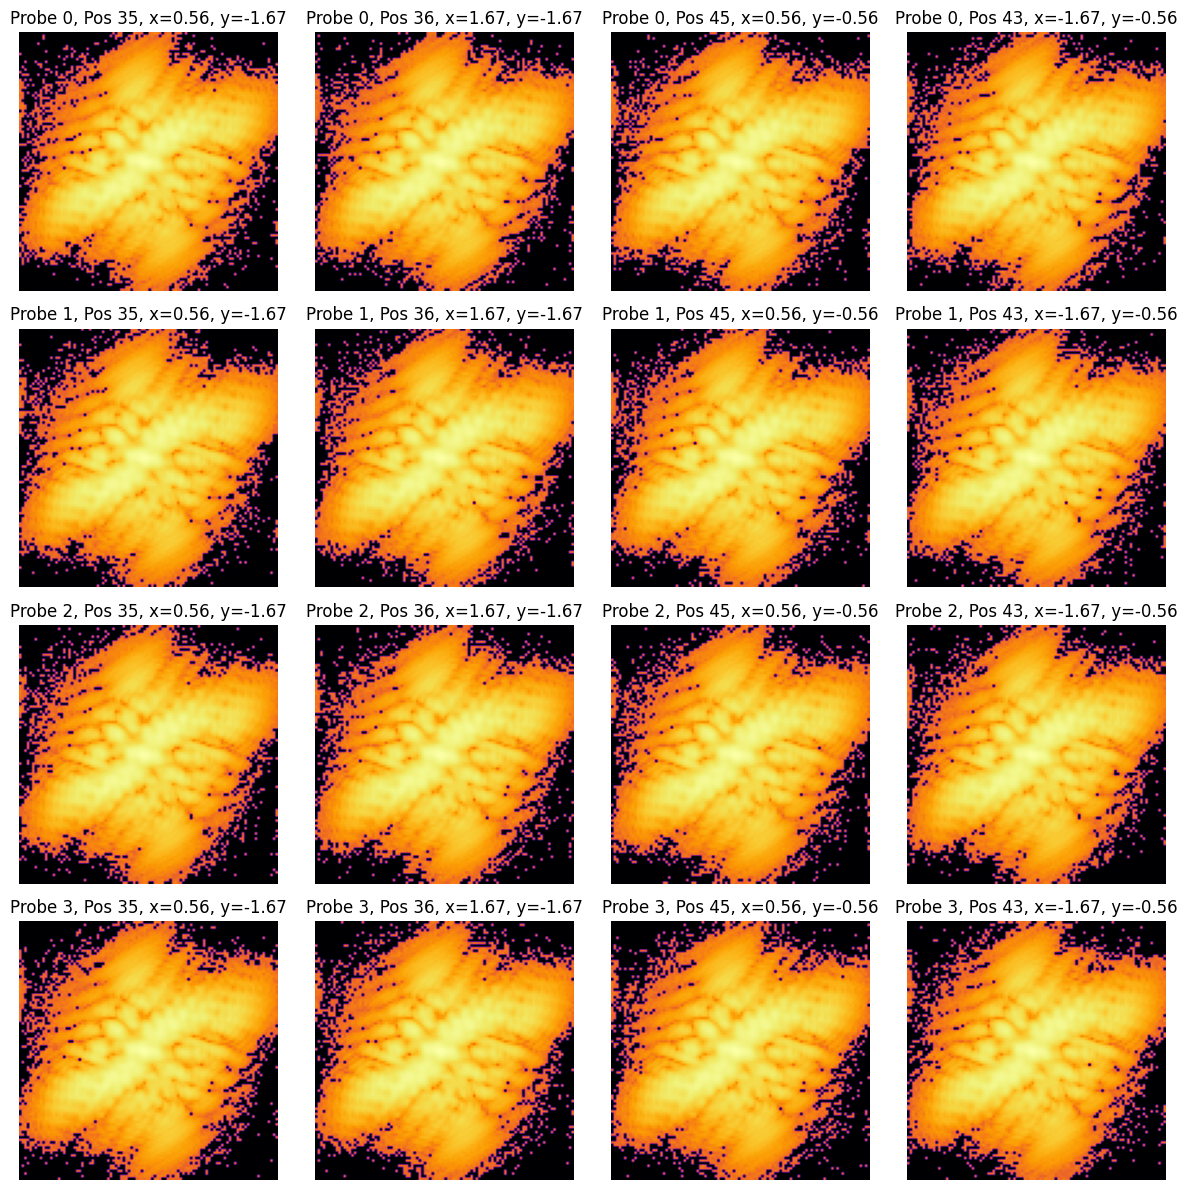

In [108]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))

#scan_indices = [35, 36, 45, 43]
scan_indices = [35, 36, 45, 43]
probe_numbers = [0, 1, 2, 3]

for i, probe_number in enumerate(probe_numbers):      # rows
    for j, scan_idx in enumerate(scan_indices):       # columns
        '''
        axes[i, j].imshow(
            (I_sim[probe_number, scan_idx].cpu()),
            cmap='inferno',
            vmin=0,
            vmax=1e6
        )
        '''
        
        axes[i, j].imshow(
            np.log10(I_sim[probe_number, scan_idx].cpu()+1e-8),
            cmap='inferno',
        )
        
        axes[i, j].set_title(f'Probe {probe_number}, Pos {scan_idx}, x={positions[scan_idx, 0].item():.2f}, y={positions[scan_idx, 1].item():.2f}')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

# Let's integrate the diffraction pattern to see STXM-like images

Summed intensity shape: torch.Size([4, 10, 10])


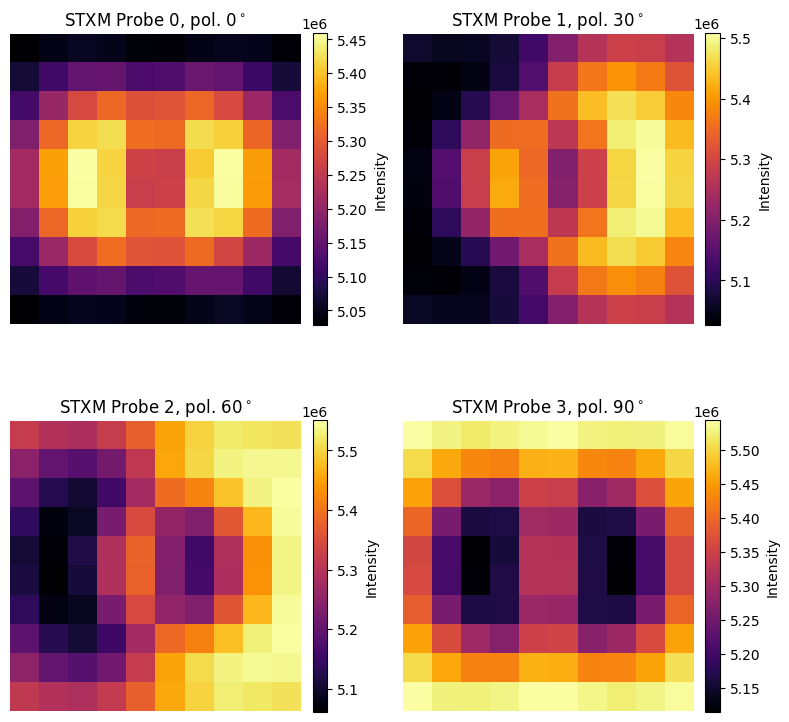

In [109]:
I_sum = I_sim.sum(dim=3)
I_sum = I_sum.sum(dim=2)

I_sum = I_sum.reshape(len(probes), len(xshiftvec), len(yshiftvec))  # Reshape to (N_probes, H, W)
print('Summed intensity shape:', I_sum.shape)  # (N_probes, H, W)

n_probes = len(probes)
ncols = min(2, n_probes)
nrows = (n_probes + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)

for i in range(n_probes):
    r = i // ncols
    c = i % ncols
    ax = axes[r, c]

    im = ax.imshow(I_sum[i].cpu(), cmap='inferno')
    ax.set_title(f'STXM Probe {i}, pol. {pol_angles[i]}$^\\circ$')
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Intensity')

# Hide any unused subplot panels.
for i in range(n_probes, nrows * ncols):
    r = i // ncols
    c = i % ncols
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()

# Optimise the Object
### Going from diffraction pattern to $A_1$, $A_2$, $C$, $\phi(r)$, $\theta(r)$
This is where I will use Autograd to minimise the loss function. I will find the gradient of the loss function in terms of $A_1$, $A_2$, $C$, $\phi(r)$, $\theta(r)$ and use that to descend the loss surface.

Here I cycle through all probes $j$ at each position $k$.

In [110]:
import torch

def optimize_object(probes, scan, I_meas, H, W, num_iterations=100, device=None):
    """
    Reconstruct theta, phi, C, A1, A2 from measured diffraction patterns.

    Parameters
    ----------
    probes : list[Probe]
        List of polarized probes.
    scan : ScanTrajectory
        Scan positions.
    I_meas : torch.Tensor
        Measured intensities, shape (N_probes, N_scan, Hdet, Wdet)
    H, W : int
        Object map size.
    num_iterations : int
        Number of optimization steps.
    device : torch.device or str
        Device to use.
    """
    if device is None:
        device = I_meas.device

    eps = 1e-8
    cdtype = torch.complex64

    # Learnable parameters
    theta = torch.nn.Parameter(torch.rand((H, W), device=device) * 0.01 + torch.pi/2)
    phi   = torch.nn.Parameter(torch.rand((H, W), device=device) * 0.1 + torch.pi/2)

    optimizer = torch.optim.Adam([
        {"params": [theta, phi], "lr": 5e-1},
        {"params": [C, A1, A2], "lr": 1e-5},
    ])

    loss_history = []

    for iteration in range(num_iterations):
        optimizer.zero_grad(set_to_none=True)

        # Build Jones object from current parameters
        neel = NeelObject(C, A1, A2)
        J = neel.build_jones(theta, phi)
        obj = JonesObject(J)

        # Forward model
        model = ForwardModel(obj, Propagator(), Detector())
        I_pred = model.simulate_all(probes, scan)

        # Amplitude-based ptychographic loss
        loss = torch.mean((torch.sqrt(I_pred + eps) - torch.sqrt(I_meas + eps)) ** 2)#+ 1e-1 * (torch.var(theta) + torch.var(phi)) # Add small regularization to encourage smoothness in theta and phi

        loss.backward()
        optimizer.step()

        loss_history.append(loss.item())

        if iteration % 1 == 0:
            print(f"Iter {iteration:4d} | Loss = {loss.item():.6e}")

    return {
        "theta": theta.detach(),
        "phi": phi.detach(),
        "C": C.detach(),
        "A1": A1.detach(),
        "A2": A2.detach(),
        "loss_history": loss_history,
    }

In [111]:
# I_meas should be your simulated or measured data tensor
# shape: (N_probes, N_scan, Hdet, Wdet)

result = optimize_object(
    probes=probes,
    scan=scan,
    I_meas=I_sim,   # or your measured data
    H=H,
    W=W,
    num_iterations=5,
    device=device,
)

theta_rec = result["theta"]
phi_rec   = result["phi"]
C_rec     = result["C"]
A1_rec    = result["A1"]
A2_rec    = result["A2"]
loss_history = result["loss_history"]

Iter    0 | Loss = 5.443236e-01
Iter    1 | Loss = 3.790692e-01
Iter    2 | Loss = 3.338132e-01
Iter    3 | Loss = 3.063994e-01
Iter    4 | Loss = 3.091138e-01


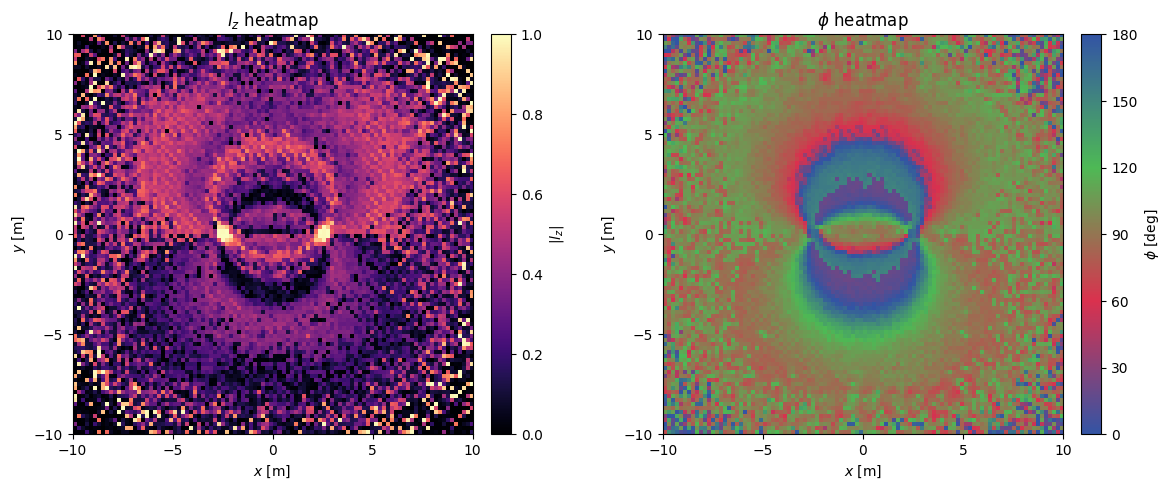

(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': '$l_z$ heatmap'}, xlabel='$x$ [m]', ylabel='$y$ [m]'>,
        <Axes: title={'center': '$\\phi$ heatmap'}, xlabel='$x$ [m]', ylabel='$y$ [m]'>],
       dtype=object))

In [112]:
plot_theta_phi_maps(theta_rec, phi_rec, Lx, Ly,theta_cmap='magma',
                       phi_cmap=RGB_scale, label_axes=True)

In [113]:
print("C_rec", C_rec)
print("A1_rec", A1_rec)
print("A2_rec", A2_rec)

C_rec tensor(50.+50.j)
A1_rec tensor(0.5000+5.j)
A2_rec tensor(0.8000+5.j)


# Optimise the Probe and the Object Simultaneously

First make an initial probe with approximately the correct shape.

## Optimise object and probe with batches
This has now been put into a Reconstruction class

In [ ]:
# I_meas should be your simulated or measured data tensor
# shape: (N_probes, N_scan, Hdet, Wdet)
random_object = False
checkpoint_path = "checkpoint.pt"

if os.path.exists(checkpoint_path):
    recon = Reconstruction.load(
        checkpoint_path,
        scan=scan,
        pol_angles=pol_angles,
        I_meas=I_sim,
        fluence=fluence,
        RGB_scale=RGB_scale,
        Lx=Lx,
        Ly=Ly,
        device=device,
    )
    print(f"Loaded checkpoint from {checkpoint_path}")
else:
    recon = Reconstruction.from_initial_guess(
        scan=scan,
        pol_angles=pol_angles,
        I_meas=I_sim,
        H=H,
        W=W,
        Lx=Lx,
        Ly=Ly,
        fluence=fluence,
        RGB_scale=RGB_scale,
        C=C,
        A1=A1,
        A2=A2,
        device=device,
        random_object=random_object,
    )
    recon.save(checkpoint_path)
    print(f"Created initial checkpoint at {checkpoint_path}")

plot_probe_maps(recon.probe_amplitude.detach().cpu().numpy(), Lx, Ly)

# Explicit usage with no notebook-global fallback inside Reconstruction:
# recon = Reconstruction.load(
#     "checkpoint.pt",
#     scan=scan,
#     pol_angles=pol_angles,
#     I_meas=I_sim,
#     fluence=fluence,
#     RGB_scale=RGB_scale,
#     Lx=Lx,
#     Ly=Ly,
#     device=device,
# )
# result = recon.run()
result = recon.run(
    num_iterations=500,
    batch_size=20,
    checkpoint_path=checkpoint_path,
    checkpoint_every=100,
)

theta_rec_3 = result["theta"]
phi_rec_3 = result["phi"]
probe_amplitude_rec_3 = result["probe_amplitude"]
C_rec_3 = result["C"]
A1_rec_3 = result["A1"]
A2_rec_3 = result["A2"]
loss_history_3 = result["loss_history"]

ValueError: Missing required runtime arguments for load(): ['scan', 'I_meas', 'fluence', 'RGB_scale']

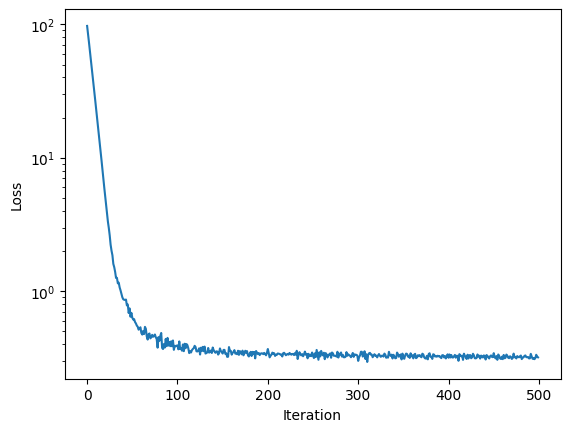

In [95]:
plt.plot(loss_history_3)
plt.ylabel('Loss')
plt.xlabel('Iteration')
plt.yscale('log')
plt.show()

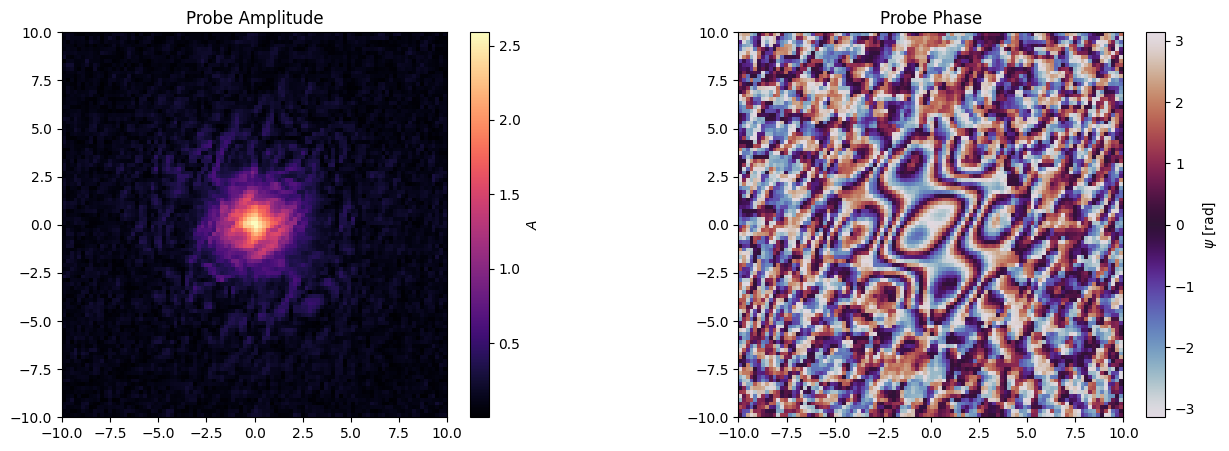

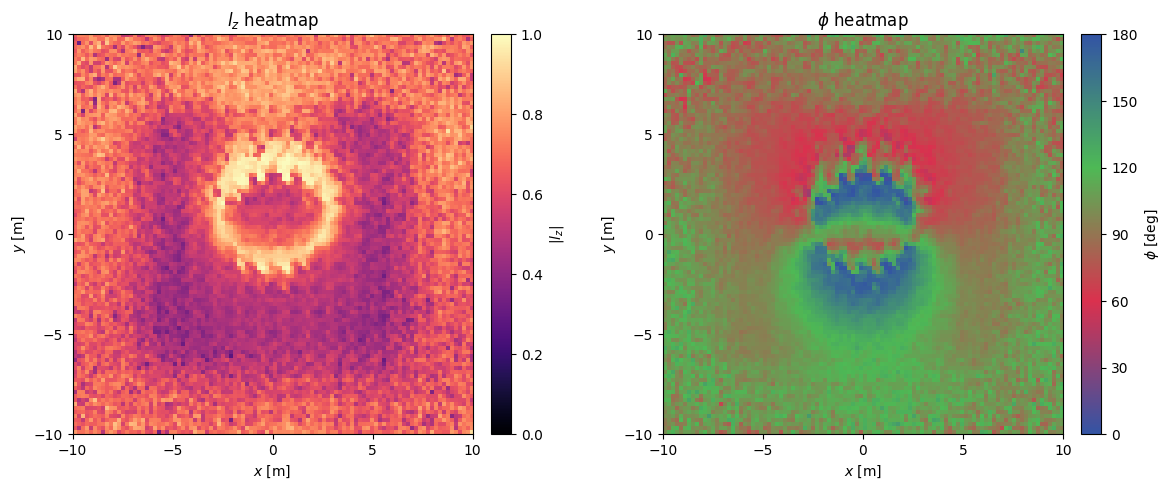

(<Figure size 1200x500 with 4 Axes>,
 array([<Axes: title={'center': '$l_z$ heatmap'}, xlabel='$x$ [m]', ylabel='$y$ [m]'>,
        <Axes: title={'center': '$\\phi$ heatmap'}, xlabel='$x$ [m]', ylabel='$y$ [m]'>],
       dtype=object))

In [97]:
plot_probe_maps(probe_amplitude_rec_3.detach().cpu().numpy(), Lx, Ly)
plot_theta_phi_maps(
    theta_rec_3.detach().cpu().numpy(),
    phi_rec_3.detach().cpu().numpy(),
    Lx,
    Ly,
    theta_cmap='magma',
    phi_cmap=RGB_scale,
    label_axes=True,
)